# WIMPYDD $\frac{dR}{dE}$

OJO - La primera vez que se ejecuta este notebook se recomienda leer y revisar paso por paso, una vez se tenga todo seguro ya se puede ejecutar todo de vez.

### IMPORTS

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos
import numpy as np    # librería numérica
import matplotlib.pyplot as plt  # para crear gráficos
import math as m


from scipy import special
from scipy.stats import norm


#Ruta de la carpeta donde se encuentra el codigo ANAIS
ANAIS_rel_path = 'Libs/ANAIS'


ANAIS_abs_path = os.path.realpath(ANAIS_rel_path)   
sys.path.append(ANAIS_abs_path)
print(ANAIS_abs_path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS


## Instalación de librerías

En primer lugar tenemos que instalar/compilar el paquete WIMPYDD. En este ejemplo lo vamos a instalar en la carpeta: "/libs" por lo que emplearemos la ruta relativa desde la ubicación del archivo. En caso de instalarlo en otra ubicación deberemos usar la ruta absoluta de la carpeta.

In [2]:
#Ruta de la carpeta donde se encuentra WIMPYDD
WIMPYDD_rel_path = 'Libs/WIMPYDD'


WIMPYDD_abs_path = os.path.realpath(WIMPYDD_rel_path)   
sys.path.append(WIMPYDD_abs_path)


print(WIMPYDD_abs_path)

/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD


## Importamos las librerías necesarias

Procedemos a incorporar las librerías al código y de esta forma poder usar sus funciones.

In [3]:
#Importamos WIMPYDD

from package import *

## POSIBLES FALLOS

Suele dar problemas con las versiones mas recientes de python. A mi me funciona con la 3.9.12.

##### WIMPYDD

Esta librería es la que mas fallos me ha dado a la hora de importarla, como solución he modificado el archivo "package.py" quitando alguna cosa que daba problemas y que en principio no vamos a usar (Los elementos Calcio y Wolframio). El archivo modificado esta en la carpeta "/Patch". Hay que copiarlo en la carpeta donde se encuentre instalada la libreria. 

Ademas, hay que modificar la linea 158 con la ruta absoluta donde se encuentre instalada la libreria. (Mas arriba se imprime esta ruta al importar las librerias)

## Importar las nuevas funciones

In [4]:
def numero_a_fecha(numero_dia):

    numero_dia=numero_dia+81

    if numero_dia>365:
        numero_dia=numero_dia-365
    
    dias_por_mes = [
        31, 28, 31,  # enero, febrero, marzo
        30, 31, 30,  # abril, mayo, junio
        31, 31, 30,  # julio, agosto, septiembre
        31, 30, 31   # octubre, noviembre, diciembre
    ]

    dia_restante = numero_dia
    for mes, dias in enumerate(dias_por_mes):
        if dia_restante <= dias:
            dia = dia_restante
            return int(dia), int(mes) + 1
        dia_restante -= dias

def print_mw_c(a: float = 3.0,
               b: float = 1.75e4,
               n: int   = 150,
               fmt: str = "{: .8e}",
               elems_per_line: int = 8,
               var_name: str = "mw",
               const: bool = True) -> None:
    """
    Genera el vector geométricamente espaciado con np.geomspace y lo imprime
    como un literal de array de C que puedes copiar‑y‑pegar directamente.

    Parámetros
    ----------
    a, b : float
        Extremos del rango geométrico.
    n : int
        Cantidad de puntos (valor por defecto 150).
    fmt : str
        Formato de cada número (por defecto 8 decimales en notación exponencial).
    elems_per_line : int
        Cantidad de elementos por línea (para mejorar la legibilidad).
    var_name : str
        Nombre de la variable C que se declarará.
    const : bool
        Si True se añade `const` al principio de la declaración.
    """
    # 1. Generamos el vector
    arr = np.geomspace(a, b, n)

    # 2. Construimos la línea de apertura
    const_str = "const " if const else ""
    header = f"static {const_str}double {var_name}[{n}] = {{"
    print(header)

    # 3. Imprimimos los valores, 8 por línea (puedes cambiar `elems_per_line`)
    line = "    "  # sangría de 4 espacios
    for i, val in enumerate(arr, start=1):
        line += fmt.format(val) + ", "
        if i % elems_per_line == 0:
            # terminamos la línea
            print(line.rstrip(", "))
            line = "   ,"  # reiniciamos sangría

    # Si quedó algo sin imprimir
    if line.strip():
        print(line.rstrip(", "))

    # 4. Cierre
    print("};")
    
def _fmt_val(val: float) -> str:
    """
    Devuelve la cadena de `val` con:
        * 2 decimales por defecto
        * Si el último decimal es 0 → se muestra una sola cifra decimal
        * Si ambos decimales son 0 → se muestra “.0”
    """
    s = f"{val:.2f}"          # 3.00 → "3.00", 3.10 → "3.10", 3.12 → "3.12"
    s = s.rstrip('0').rstrip('.')  # 3.00→"3", 3.10→"3.1", 3.12→"3.12"

    # Si quedó sin punto, añadimos ".0" (caso 3.00)
    if '.' not in s:
        s += ".0"
    return s

def print_hist_mw_c(mw: np.ndarray,
                    var_name: str = "hist_mw",
                    elems_per_line: int = 6,
                    const: bool = True) -> None:
    """
    Imprime en stdout una declaración C de un array de cadenas con el
    nombre `hist_mw_<valor>`.  
    Se usa la función interna `_fmt_val` para el formato solicitado.
    """
    const_str = "const " if const else ""
    n = len(mw)

    print(f"static {const_str}const char *{var_name}[{n}] = {{")
    line = "    "

    for i, v in enumerate(mw, start=1):
        txt = f"hist_mw_{_fmt_val(v)}"
        line += f'"{txt}", '
        if i % elems_per_line == 0:
            print(line.rstrip(", "))
            line = "   ,"

    if line.strip():               # resto de elementos que no llenaron la línea
        print(line.rstrip(", "))
    print("};")


    return N_exp/N_teo


La librería posee la función diff_rate que se define de la forma (traduccion no fiable, hecha con IA de la documentacion de WIMPYDD)

# `diff_rate`

diff_rate(target, hamiltonian, mchi, spin, er, vmin, delta_eta,
              delta=0.0, exposure=1.0, rho=0.3, **args):

> **Descripción**  
> Calcula la tasa diferencial para la dispersión WIMP‑núcleo.

### Parámetros

| Parámetro | Tipo | Descripción |
|-----------|------|-------------|
| `target`      | objeto | Pertenece a la clase `target`. |
| `hamiltonian` | objeto | Pertenece a la clase `eft_hamiltonian`. |
| `mchi`        | float | Masa del WIMP en GeV. |
| `spin`        | int/float | Espín del WIMP. |
| `er`          | float | Energía de rebote nuclear en keV. |
| `vmin`        | np.ndarray | Valores de *vmin* en km/s donde se muestrea *delta η*. |
| `delta_eta`   | np.ndarray | Contribuciones de los flujos *vmin* a la función del halo en (km/s)⁻¹. |
| `delta`       | float | Separación de masas para la dispersión inelástica, en keV. *(default = 0)* |
| `exposure`    | float | Exposición del experimento. *(default = 1)* |
| `rho`         | float | Densidad local de materia oscura en GeV/cm³. *(default = 0.3)* |
| `args`        | dict | Argumentos definidos por el usuario |

### Salida

- **Tipo**: `float`  
- **Descripción**: Tasa diferencial en unidades de eventos / kg / día / keV.



De aqui se puede ver que necesitamos definir los objetos *hamiltonian* y *target*. Procedemos a explicarlos a continuación.

# `Target`

> **Descripción**  
> Crea una instancia del objetivo (target)  
> Cada símbolo de elemento se interpreta como un objeto de la clase `element`.  

## Parámetros de la función

| Parámetro | Tipo | Descripción |
|-----------|------|-------------|
| `formula` | `str` | Cadena con la fórmula química. La primera letra de cada símbolo debe ser mayúscula (p.ej. `"C3F8"`). Cada símbolo corresponde a un objeto de la clase `element`. |
| `verbose` | `bool` | Si `True`, imprime información sobre los archivos externos accedidos. Por defecto `False`. |

## Atributos creados

| Atributo | Tipo | Descripción |
|----------|------|-------------|
| `a_tot` | `float` | Número total de masas atómicas (suma de los números atómicos de cada elemento). |
| `element` | `np.ndarray` | Matriz que contiene los objetos de la clase `element` correspondientes a cada símbolo en la fórmula. |
| `formula` | `str` | Cadena original de la fórmula. |
| `mass` | `float` | Masa total promedio (suma de las masas atómicas). |
| `n` | `np.ndarray` | Cantidad de átomos de cada elemento en la fórmula. |
| `n_targets` | `int` | Número de tipos distintos de elementos. |
| `nt_kg` | `np.ndarray` | Masa total en kilogramos por mol de cada elemento (usando su peso atómico). |



# `eft_hamiltonian`

**Descripción**  
Esta función configura el Hamiltoniano de un modelo de campo efectivo a partir de los coeficientes de Wilson especificados.  


## Parámetros

| Parámetro            | Tipo   | Descripción |
|----------------------|--------|-------------|
| `name`               | `str`  | Nombre del modelo de Hamiltoniano. Se suele usar el mismo nombre que la carpeta donde se guardan las funciones de respuesta. |
| `wilson_coefficients`| `dict` | Diccionario que contiene los coeficientes de Wilson. Las llaves son los índices de los coeficientes y los valores son **funciones** que devuelven el coeficiente en función de diferentes parámetros |
| `q_norm`             | `float`| Normalización para la variable `q`. Por defecto es `1.0`. Se utiliza para extraer la dependencia en el momento de los coeficientes de Wilson y tratarla de manera diferente. |



In [5]:
#Numero de puntos del plot
n_energias=1000

#Valor mínimo de masa
energias_min=0.01

#Valor máximo de masa
energias_max=100

energies = np.linspace(energias_min,energias_max,n_energias)
#sección eficaz SI(cm^-2)
si=1                                 

array_masas=np.array([2,10,50,100,500,1000])

print(array_masas)

[   2   10   50  100  500 1000]


In [6]:
def carga_rate_SDp(m):
    archivo="rate_DMAnalysis_SDp_fitSim.root"
    file = uproot.open(archivo)
    file.keys()
    nombre = "rate_SDp_mw"
    nombre += f'{m:.1f}'            # f‑string con formato fijo
    graph = file[nombre]
    longitud=len(graph.axis().centers())

    datos=np.zeros((2,longitud))
    datos[0]=graph.axis().centers()-0.04
    datos[1]=graph.values()
    
    return datos

def carga_rate_SDn(m):
    archivo="rate_DMAnalysis_SDn_fitSim.root"
    file = uproot.open(archivo)
    file.keys()

    nombre = "rate_SDn_mw"
    nombre += f'{m:.1f}'            # f‑string con formato fijo
    graph = file[nombre]
    longitud=len(graph.axis().centers())

    datos=np.zeros((2,longitud))
    datos[0]=graph.axis().centers()-0.04
    datos[1]=graph.values()
    
    return datos



In [7]:
mW=100   
DMA_n=carga_rate_SDn(mW)
DMA_p=carga_rate_SDp(mW)

print(DMA_n)

[[1.00000000e-02 1.10000000e-01 2.10000000e-01 ... 9.97100000e+01
  9.98100000e+01 9.99100000e+01]
 [1.60846673e-02 1.59818418e-02 1.58796534e-02 ... 1.63306904e-04
  1.62876226e-04 1.62446580e-04]]


## SD

Aquí definimos el hamiltoniano para Spin Dependent. Aqui tengo dudas de como se define el caso proton y neutron. Esta es la unica que tiene los coeficientes de wilson bien definidos en la librería junto con SI.



In [8]:

si=1e-36                                  


def c_tau_SD_p(sigma_p, mchi):
     hbarc2 = 0.389e-27
     mn = 0.931
     mu = mchi * mn / (mchi + mn)
     cp = np.sqrt((16.0/3.0) * np.pi * sigma_p / hbarc2) / mu
     return cp * np.array([1.0, 1.0])   # [c0, c1]


def c_tau_SD_n(sigma_n, mchi):
     hbarc2 = 0.389e-27
     mn = 0.931
     mu = mchi * mn / (mchi + mn)
     cn = np.sqrt((16.0/3.0) * np.pi * sigma_n / hbarc2) / mu
     return cn * np.array([1.0, -1.0])  # [c0, c1]




def diffrate_WIMPYDD_SD(Eee,mW,sigmaSD,t,Q,sdneutron=0,cncp=0,str_trg='Na'):

        target_1=target(str_trg) 

        if sdneutron==1:
            
        
                wc_SD={4: lambda: c_tau_SD_n(sigmaSD, mW)}

                SD = eft_hamiltonian('Spin-dependent neutron-only', wc_SD)    

                vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81,v_rot_gal=v0,v_sun_rot=vpec) 
                
                E=Eee/Q
                diff_rate_o=diff_rate(target=target_1, hamiltonian=SD, mchi=mW, energy=Eee,vmin=vmin, delta_eta=delta_eta0)
                diff_rate_o/=Q
                return diff_rate_o
        
        else:
            
        
                wc_SD={4: lambda: c_tau_SD_p(sigmaSD, mW)}

                SD = eft_hamiltonian('Spin-dependent proton-only', wc_SD)    

                vmin,delta_eta0=streamed_halo_function(day_of_the_year=t+81,v_rot_gal=v0,v_sun_rot=vpec) 
                
                E=Eee/Q
                diff_rate_o=diff_rate(target=target_1, hamiltonian=SD, mchi=mW, energy=Eee,vmin=vmin, delta_eta=delta_eta0)
                diff_rate_o/=Q

                return diff_rate_o

         
        
        
        
def rate_WIMPYDD_SD(Eee,mW,sigmaSD,t, QNa=1, QI=1,sdneutron=0,cncp=0):


        rateNa = diffrate_WIMPYDD_SD(Eee,mW,sigmaSD,t,QNa,sdneutron,cncp,str_trg='Na')
        rateI = diffrate_WIMPYDD_SD(Eee,mW,sigmaSD,t,QI,sdneutron,cncp,str_trg='I')
    
        return (rateNa*23.+rateI*127.)/(23.+127.)


def rate_WIMPYDD_Li_SD(Eee,mW,sigmaSI,t,sdneutron=0,cncp=0):

        rateLi = diffrate_WIMPYDD_SD(Eee,mW,sigmaSI,t,sdneutron,cncp,str_trg="Li")
    
        return rateLi


    

In [9]:

si=1e-36                                  

import WIMpy
from WIMpy import DMUtils as DMU
print(WIMpy.__version__)

def c_tau_SD_p(sigma_p, mchi):
     hbarc2 = 0.389e-27
     mn = 0.931
     mu = mchi * mn / (mchi + mn)
     cp = np.sqrt((16.0/3.0) * np.pi * sigma_p / hbarc2) / mu
     return cp * np.array([1.0, 1.0])   # [c0, c1]


def c_tau_SD_n(sigma_n, mchi):
     hbarc2 = 0.389e-27
     mn = 0.931
     mu = mchi * mn / (mchi + mn)
     cn = np.sqrt((16.0/3.0) * np.pi * sigma_n / hbarc2) / mu
     return cn * np.array([1.0, -1.0])  # [c0, c1]




def diffrate_NREFT_SD(Eee,mW,sigmaSD,t,Q,sdneutron=0,cncp=1,str_trg='Na23'):

        target_1=target(str_trg) 

        hbarc2 = 0.389e-27
        mn = 0.931
        mu = mW * mn / (mW + mn)
        cp = cncp*np.sqrt((16.0/3.0) * np.pi * sigmaSD / hbarc2) / mu

        cp_SD = np.zeros(20)
        cp_SD[3] = cp

        cn_SD = np.zeros(20)
        cn_SD[3] = cp

        vlag=238.0 
        sigmav=238.0/np.sqrt(2)
        vesc=544.0

        if sdneutron==0:
                
                E=Eee/Q
                diff_rate_o=DMU.dRdE_NREFT(E, mW, cp_SD, 0.0*cp_SD, str_trg, vlag=vlag, sigmav=sigmav, vesc=vesc)
                diff_rate_o/=Q
                return diff_rate_o
        
        else:
            
                E=Eee/Q
                diff_rate_o=DMU.dRdE_NREFT(E, mW, 0.0*cn_SD, cn_SD, str_trg, vlag=vlag, sigmav=sigmav, vesc=vesc)
                diff_rate_o/=Q
                return diff_rate_o

         
        
        
        
def rate_NREFT_SD(Eee,mW,sigmaSD,t, QNa=1, QI=1,sdneutron=0,cncp=1):


        rateNa = diffrate_NREFT_SD(Eee,mW,sigmaSD,t,QNa,sdneutron,cncp,str_trg='Na23')
        rateI = diffrate_NREFT_SD(Eee,mW,sigmaSD,t,QI,sdneutron,cncp,str_trg='I127')
    
        return (rateNa*23.+rateI*127.)/(23.+127.)





    

1.1.1


In [10]:
matriz_WIMPYDD_SD=np.zeros((2,len(array_masas),len(energies)))
matriz_NREFT_SD=np.zeros((2,len(array_masas),len(energies)))
si=1e-36                                  
emes = array_masas
emes = np.array(emes) 

for k in range (0,2):

    for j in range(len(emes)):
        mW=emes[j]
        rateNaI=np.zeros(len(energies))
        for i in range(len(energies)):

            matriz_WIMPYDD_SD[k,j,i]=rate_WIMPYDD_SD(energies[i],mW,si,timeAvg,sdneutron=k)
            matriz_NREFT_SD[k,j,i]=rate_NREFT_SD(energies[i],mW,si,timeAvg,sdneutron=k,cncp=1)



/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:4803: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'mchi' in global_arguments: args['mchi']=mchi
/home/borja/Documents/TFG/GeneraRitmo/Libs/WIMPYDD/package.py:4804: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if 'delta' in global_arguments: args['delta']=delta


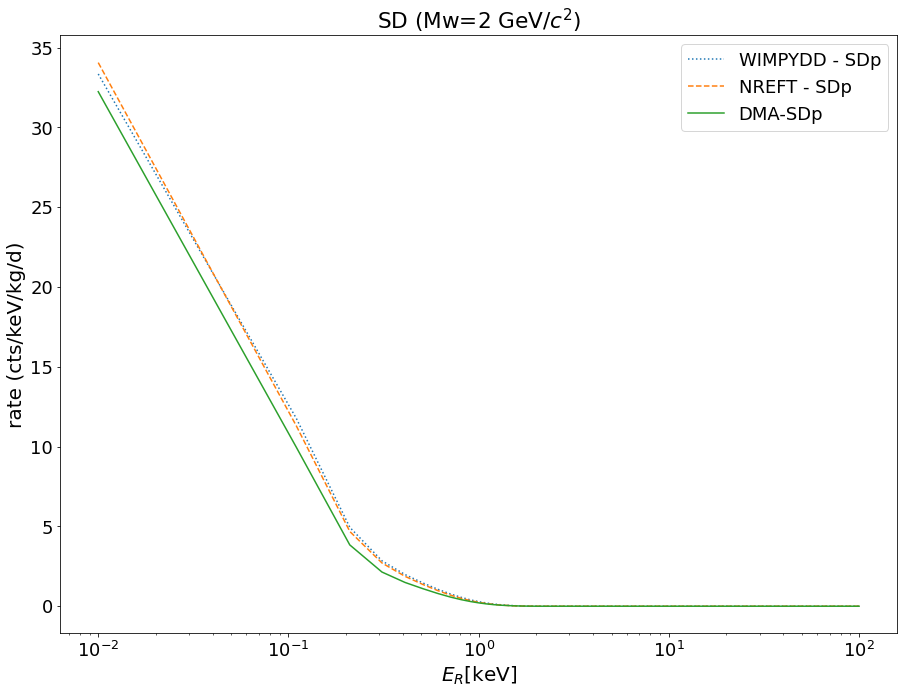

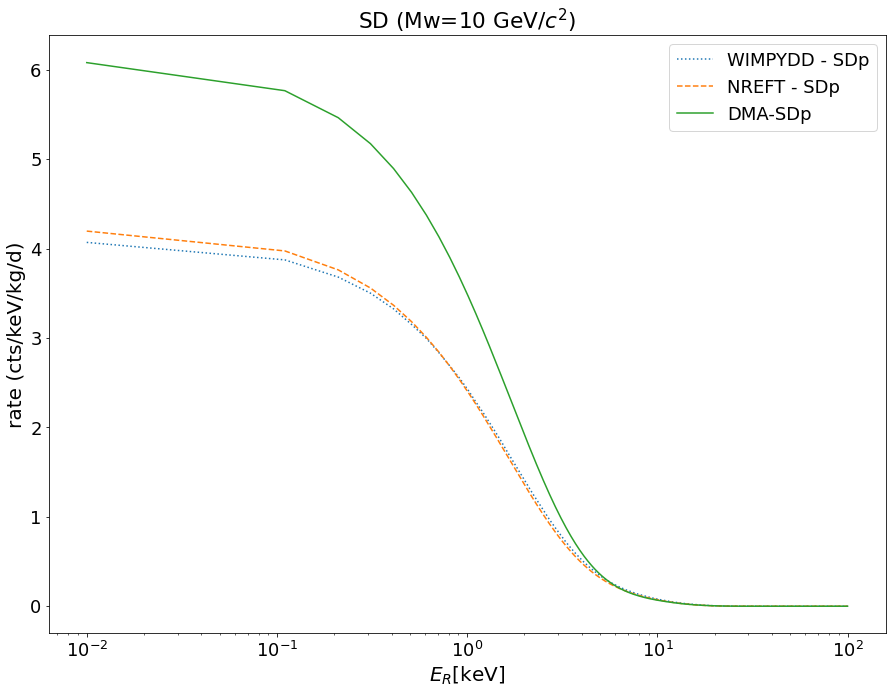

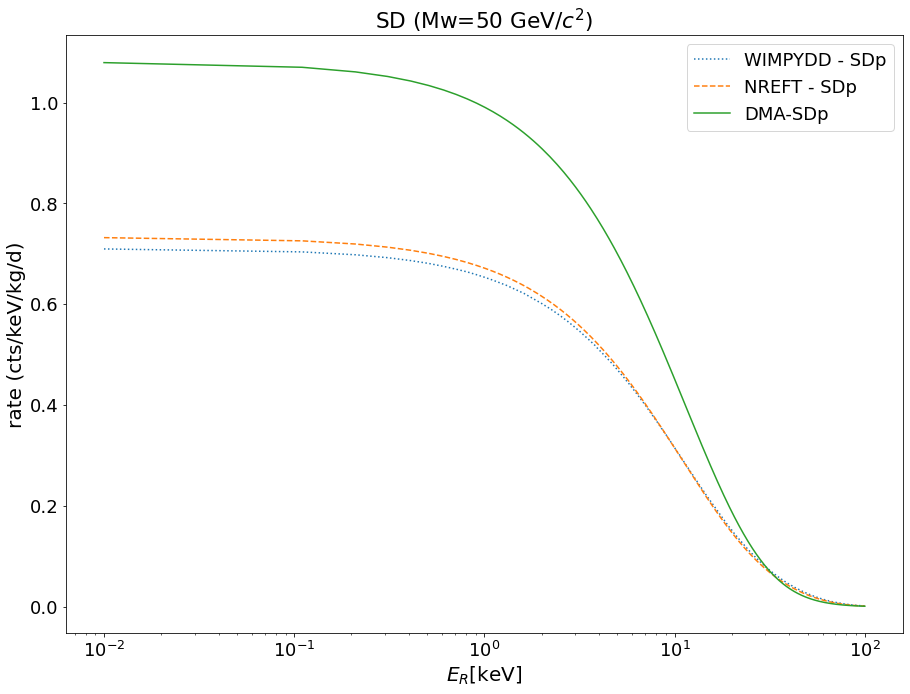

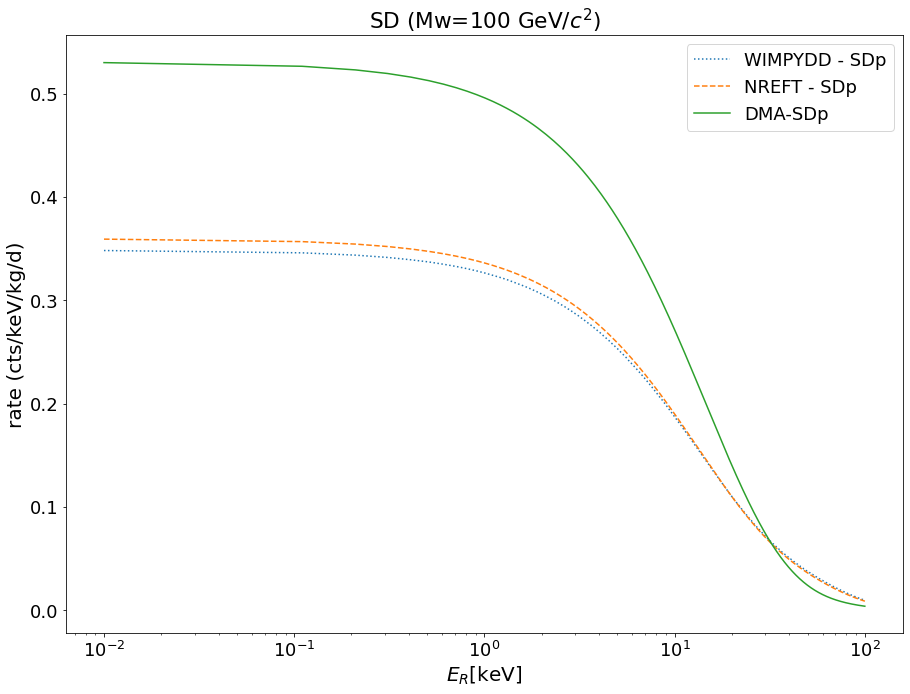

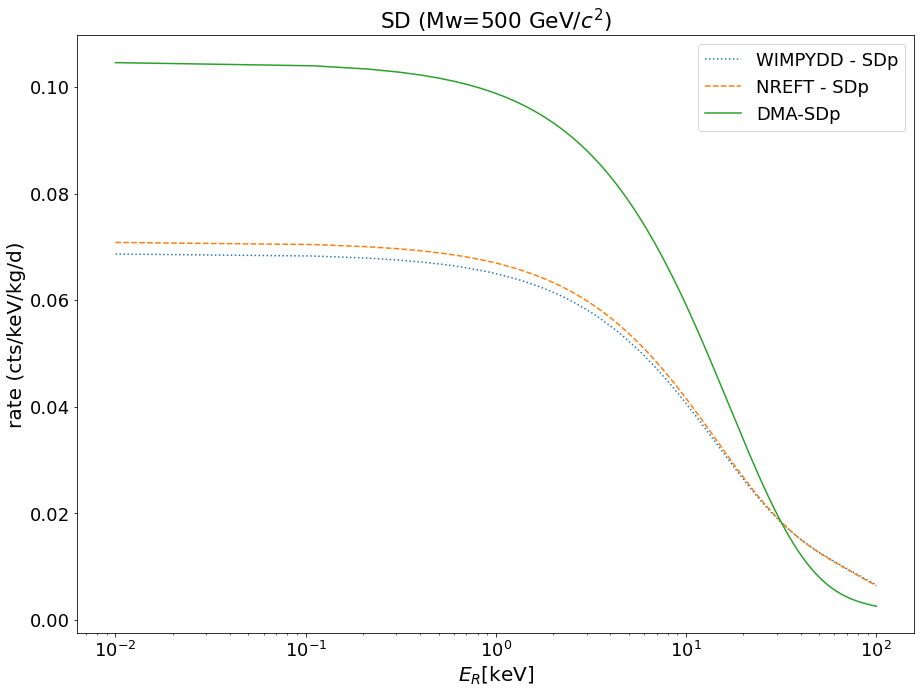

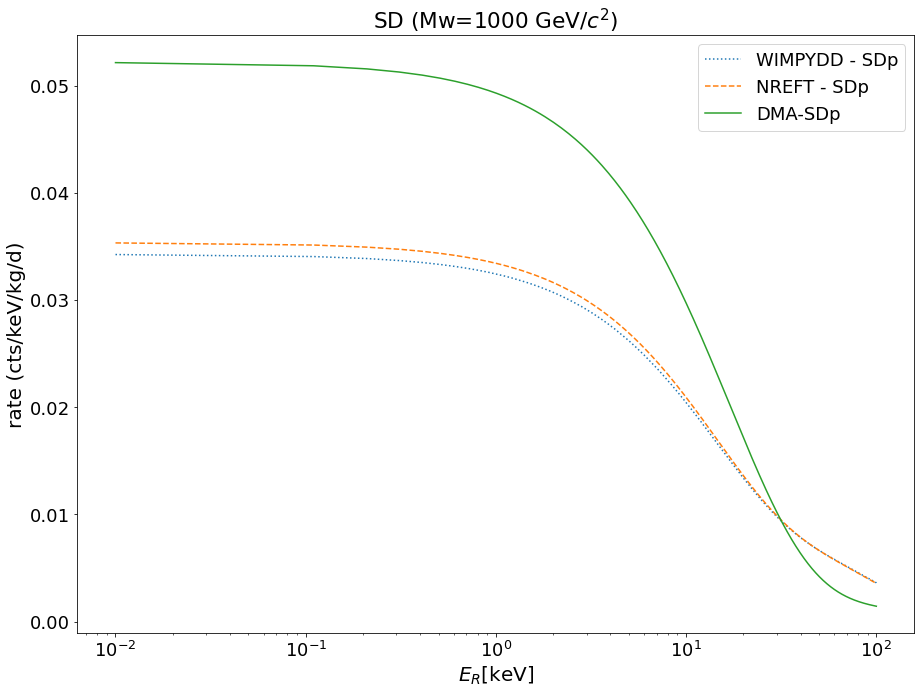

In [11]:
for j in range(len(emes)):
    mW=emes[j]
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(15, 11))
    ax = plt.subplot()

    
    ax.plot(energies,matriz_WIMPYDD_SD[0,j], label = "WIMPYDD - SDp",linestyle=':')
    #ax.plot(energies,matriz_WIMPYDD_SD[1,j], label = "WIMPYDD - SDn",linestyle=':')

    ax.plot(energies,matriz_NREFT_SD[0,j], label = "NREFT - SDp",linestyle='--')
    #ax.plot(energies,matriz_NREFT_SD[1,j], label = "NREFT - SDn",linestyle='--')
    
    
    DMA_n=carga_rate_SDn(mW)
    DMA_p=carga_rate_SDp(mW)

    ax.plot(DMA_p[0],DMA_p[1], label = "DMA-SDp",linestyle='-')
    #ax.plot(DMA_n[0],DMA_n[1], label = "DMA-SDn",linestyle='-')
    

    ax.set_title(r'SD (Mw=' + str(np.round(mW)) + ' GeV/$c^2$)')
    ax.set_ylabel(r'rate (cts/keV/kg/d)',fontsize=20)
    ax.set_xlabel(r'$E_{R}$'+ '[keV]',fontsize=20)
    ax.legend()
    #ax.set_yscale("log")
    ax.set_xscale("log")

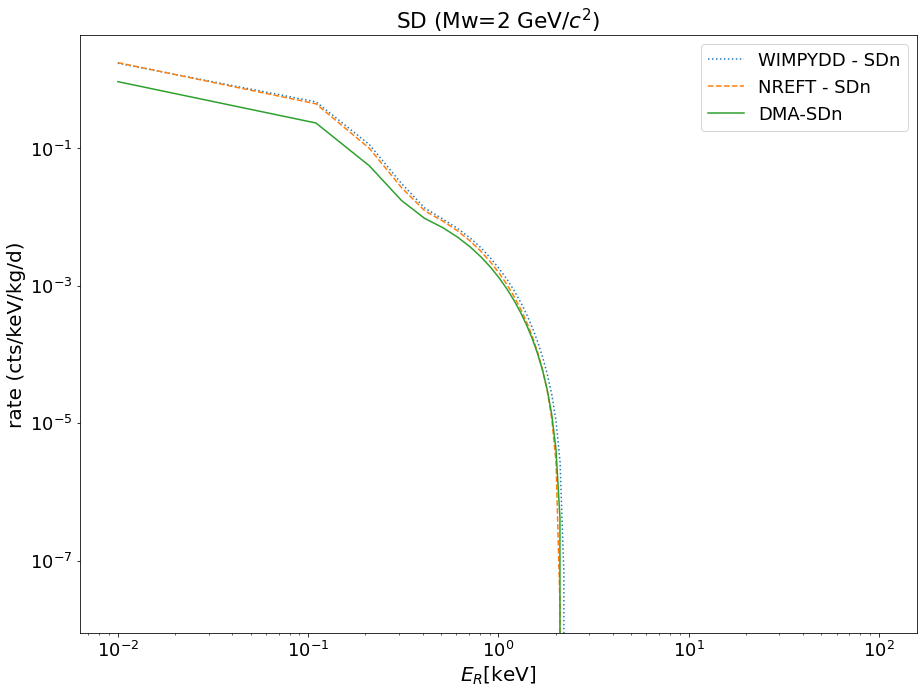

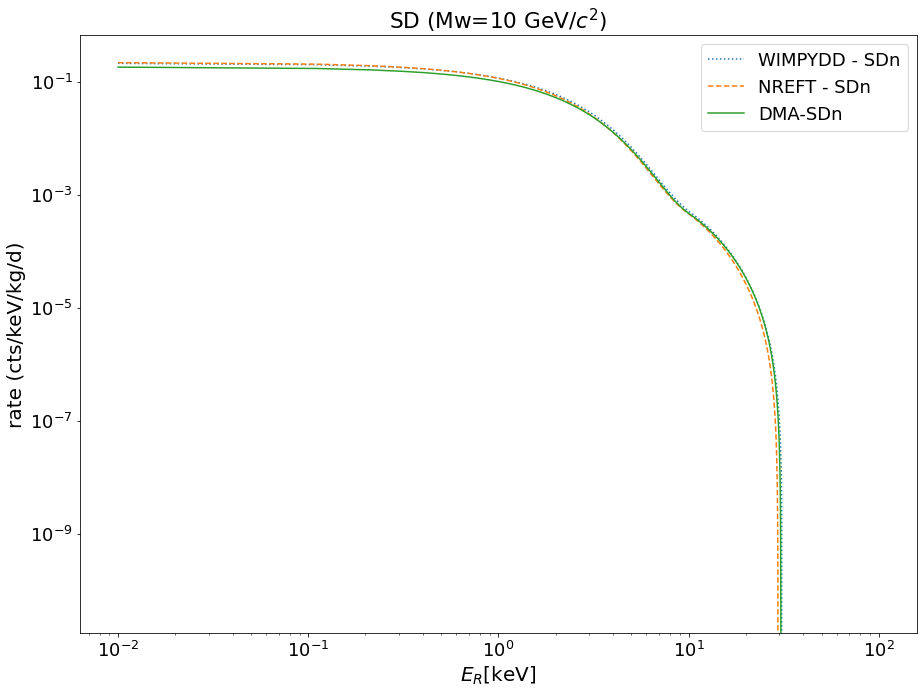

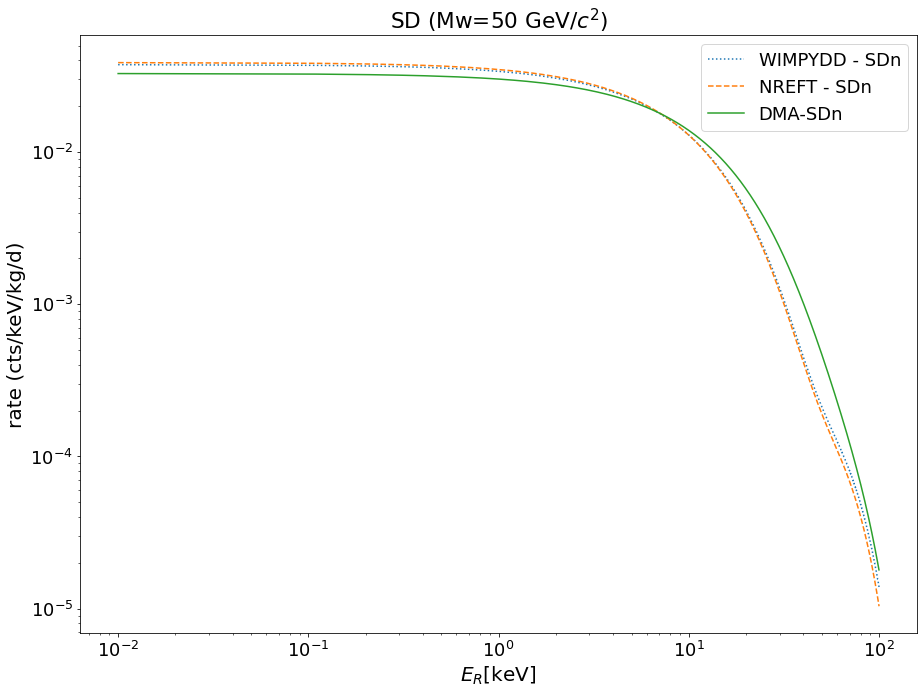

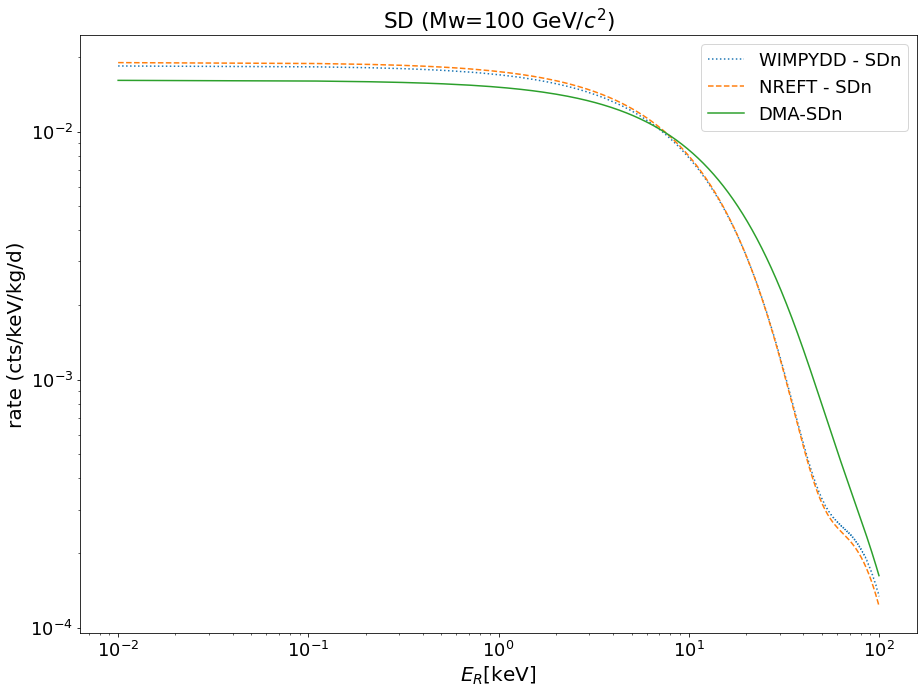

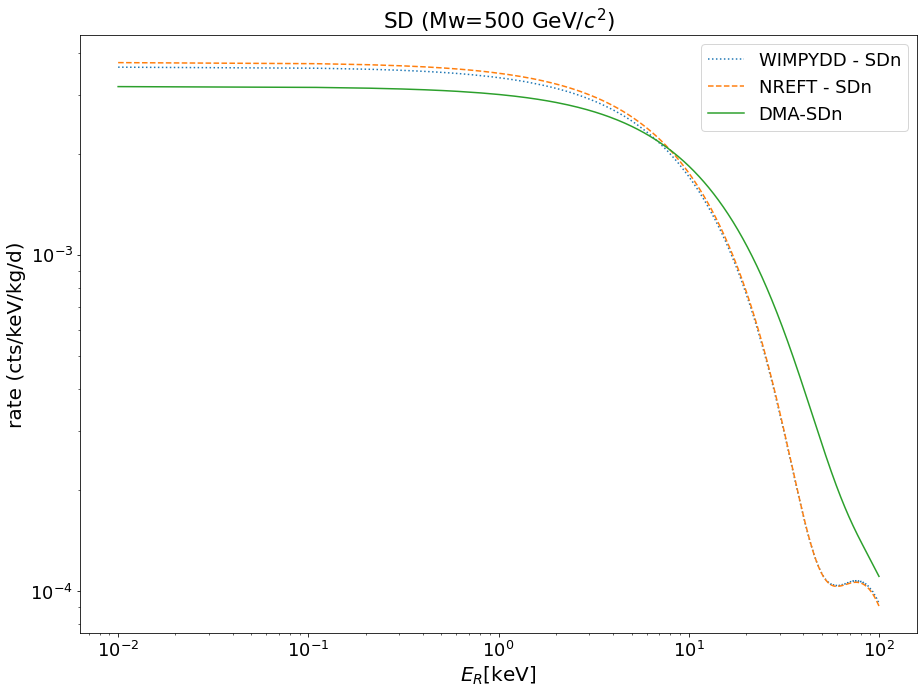

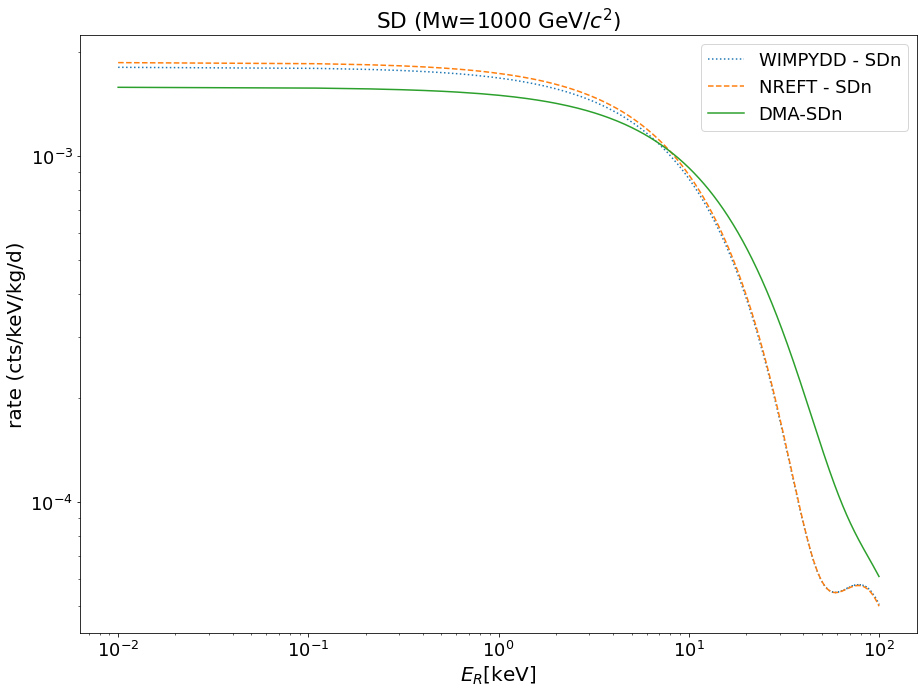

In [12]:
for j in range(len(emes)):
    mW=emes[j]
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(15, 11))
    ax = plt.subplot()

    
   
    ax.plot(energies,matriz_WIMPYDD_SD[1,j], label = "WIMPYDD - SDn",linestyle=':')

 
    ax.plot(energies,matriz_NREFT_SD[1,j], label = "NREFT - SDn",linestyle='--')
    
    
    DMA_n=carga_rate_SDn(mW)
    DMA_p=carga_rate_SDp(mW)


    ax.plot(DMA_n[0],DMA_n[1], label = "DMA-SDn",linestyle='-')
    

    ax.set_title(r'SD (Mw=' + str(np.round(mW)) + ' GeV/$c^2$)')
    ax.set_ylabel(r'rate (cts/keV/kg/d)',fontsize=20)
    ax.set_xlabel(r'$E_{R}$'+ '[keV]',fontsize=20)
    ax.legend()
    ax.set_yscale("log")
    ax.set_xscale("log")